In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

In [3]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8413
Test score: 0.8056


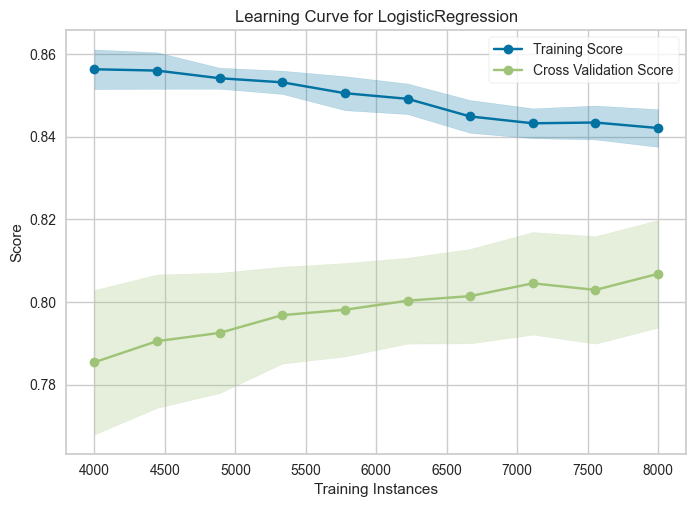

In [4]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(
    LogisticRegression(), train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y).show() 

In [5]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=1000000).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.7724
Test score: 0.7712


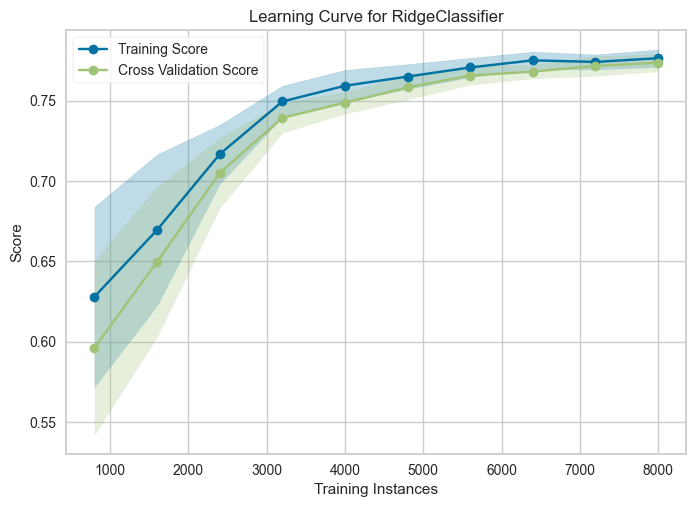

In [6]:
visualizer = LearningCurve(
    RidgeClassifier(alpha=1000000), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show()

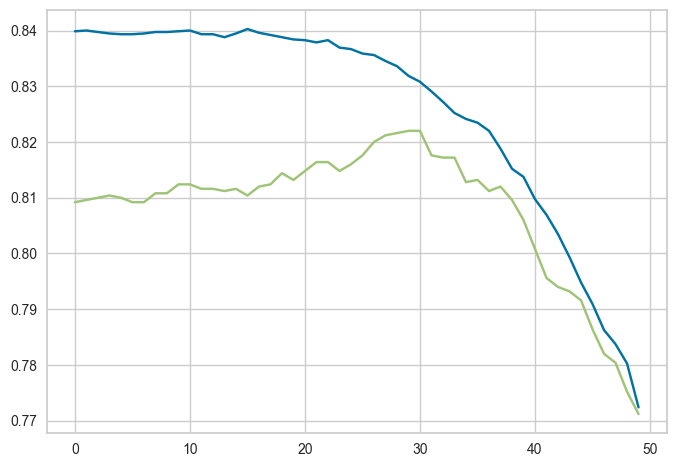

In [7]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(2, 6, 50):
  ridge = RidgeClassifier(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains)
plt.plot(tests)

In [8]:
from sklearn.linear_model import RidgeClassifier
lr = RidgeClassifier(alpha=26500).fit(X_train, y_train)

print(f"Training score: {lr.score(X_train, y_train):.4f}")
print(f"Test score: {lr.score(X_test, y_test):.4f}")

Training score: 0.8311
Test score: 0.8228


In [ ]:
from numpy import genfromtxt
dataset = genfromtxt('./data/boston-housing-dataset.csv', delimiter=',')  # had to import from kaggle, likely different
X = dataset[:,:-1]
y = dataset[:,-1]
X = np.delete(X, (0), axis=0)
y = np.delete(y, (0), axis=0)
X = np.delete(X, (0), axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [10]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)
print(f"Training score: {model.score(X_train, y_train):.4f}")
print(f"Test score: {model.score(X_test, y_test):.4f}")

Training score: 0.7698
Test score: 0.6355


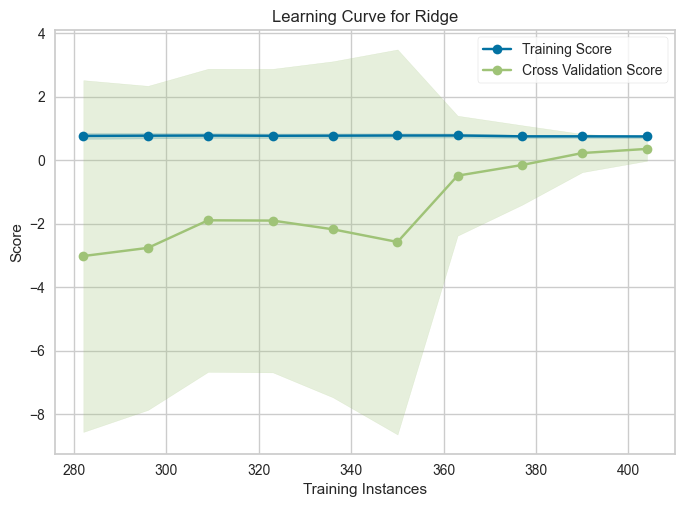

In [11]:
from yellowbrick.model_selection import LearningCurve
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=0.0001)
visualizer = LearningCurve(
    ridge, scoring='r2', train_sizes=np.linspace(0.7, 1.0, 10)
).fit(X, y) .show() 

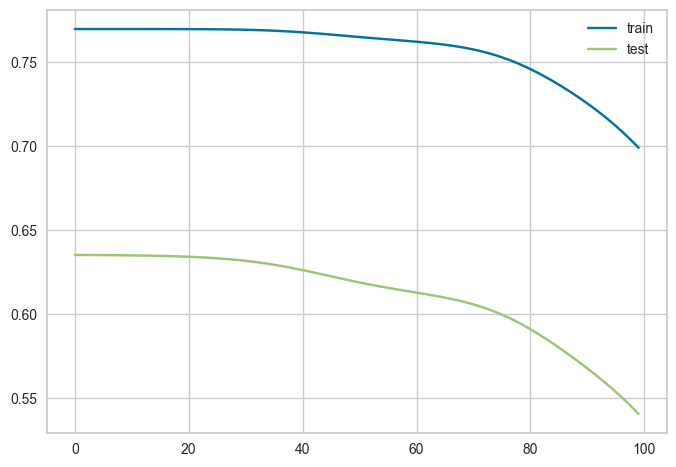

In [22]:
from sklearn.linear_model import Ridge
trains = []
tests = []

for i in np.logspace(-2, 3, 100):
  ridge = Ridge(alpha=i).fit(X_train, y_train)
  
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [23]:
lr = Ridge(alpha=0.18).fit(X_train, y_train)

print(f"Linear Regression-Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Linear Regression-Test set score: {lr.score(X_test, y_test):.2f}")

Linear Regression-Training set score: 0.77
Linear Regression-Test set score: 0.63


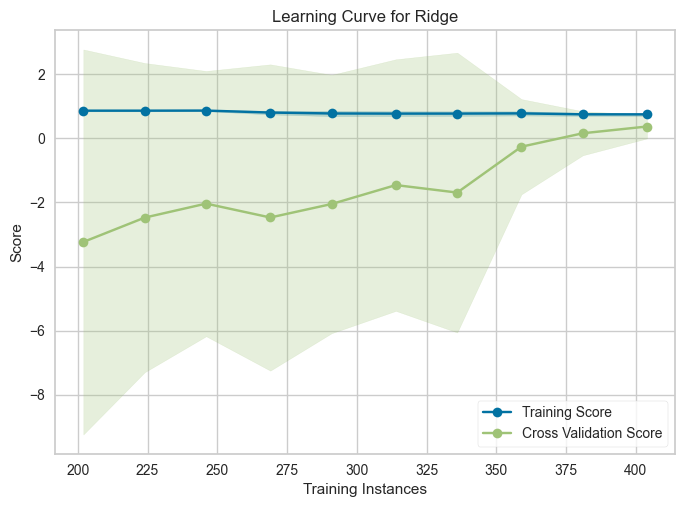

In [24]:
visualizer = LearningCurve(
    Ridge(alpha=0.18), scoring='r2', train_sizes=np.linspace(0.5, 1.0, 10)
).fit(X, y) .show() 

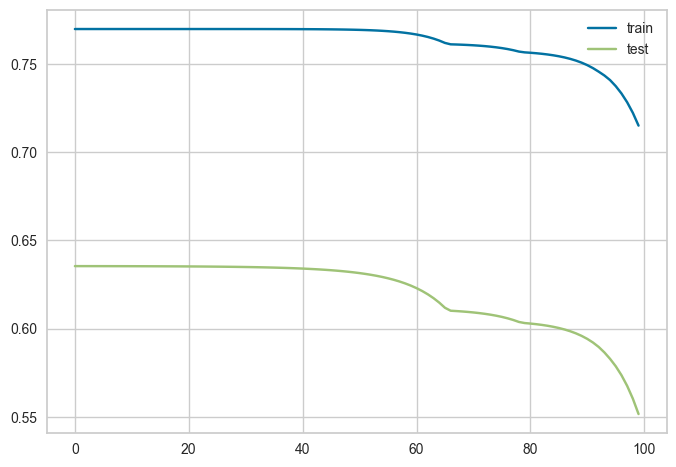

In [27]:
from sklearn.linear_model import Lasso
trains = []
tests = []
for i in np.logspace(-4, 0, 100):
  ridge = Lasso(alpha=i).fit(X_train, y_train)
  trains.append(ridge.score(X_train, y_train))
  tests.append(ridge.score(X_test, y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

In [28]:
import pandas as pd
df = pd.read_csv('./data/diabetes.csv',nrows=200)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [29]:
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.5500


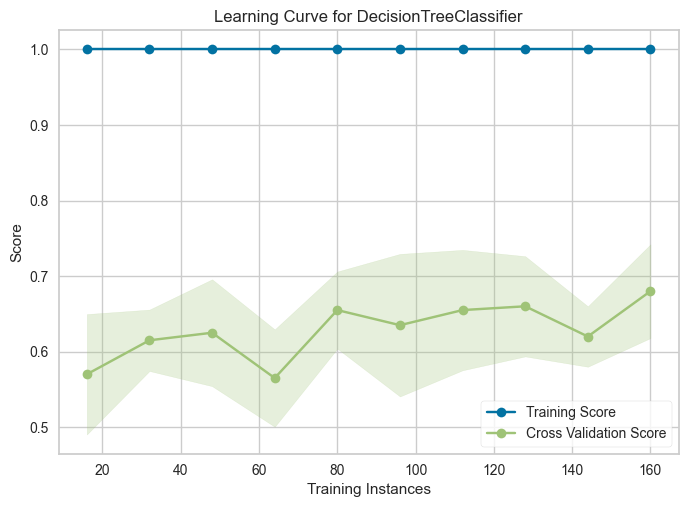

In [31]:
visualizer = LearningCurve(
    model, train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y).show()

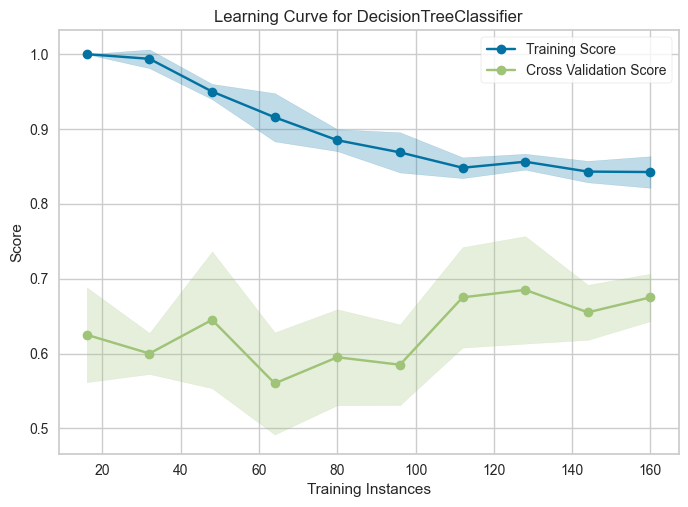

In [32]:
visualizer = LearningCurve(
    DecisionTreeClassifier(max_depth=4), train_sizes=np.linspace(0.1, 1.0, 10)
).fit(X, y) .show() 

In [33]:
df = pd.read_csv('./data/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=1).fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
from sklearn.metrics import f1_score
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 1.0000
Test score = 0.7273


In [34]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name='delta_ailerons', parser="auto")
data.data.shape

(7129, 5)

In [35]:
X = pd.get_dummies(data.data)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.6092
Test score = 0.5989


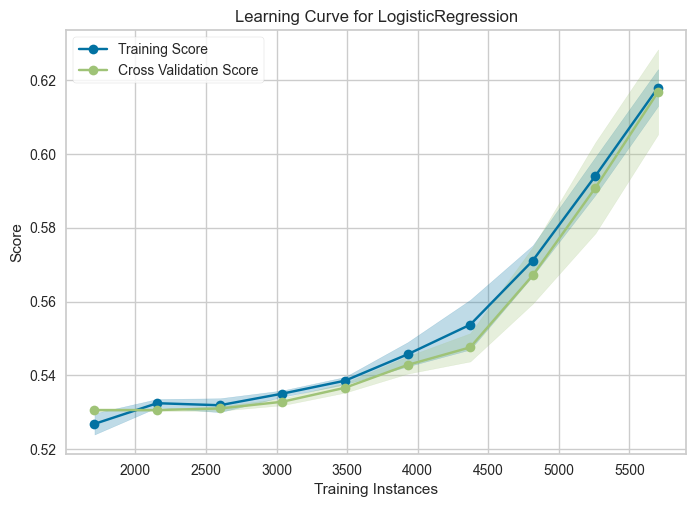

In [37]:
visualizer = LearningCurve(
    LogisticRegression(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show() 

In [38]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier().fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9390
Test score = 0.9390


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: Con

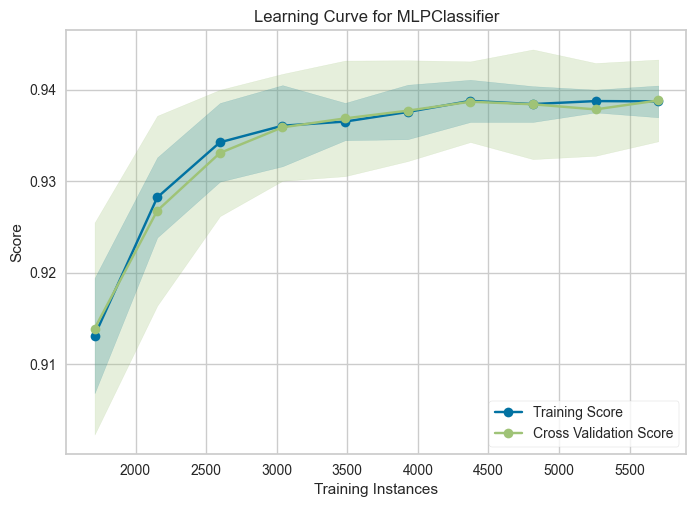

In [39]:
visualizer = LearningCurve(
    MLPClassifier(), scoring='accuracy', train_sizes=np.linspace(0.3, 1.0, 10)
).fit(X, y) .show() 

In [40]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import PolynomialFeatures
model = RidgeClassifier(alpha=0.001).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
y_train_pred = model.predict(PolynomialFeatures(2).fit_transform(X_train))
y_pred = model.predict(PolynomialFeatures(2).fit_transform(X_test))
print("Train score = %.4f" % accuracy_score(y_train, y_train_pred))
print("Test score = %.4f" % accuracy_score(y_test, y_pred))

Train score = 0.9392
Test score = 0.9362


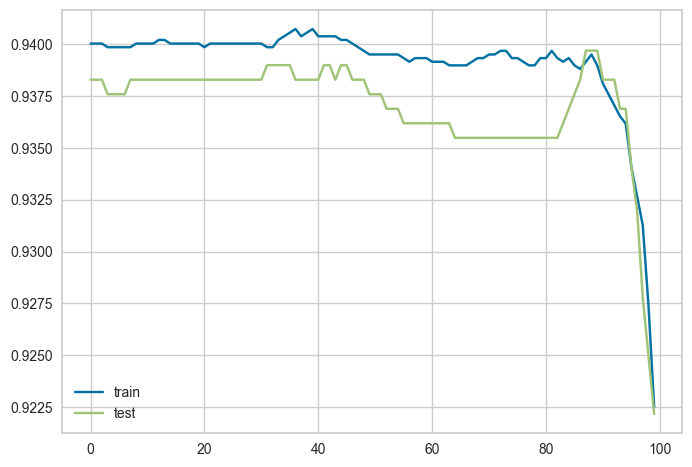

In [41]:
from sklearn.linear_model import RidgeClassifier
trains = []
tests = []
for i in np.logspace(-7, 0, 100):
  ridge = RidgeClassifier(alpha=i).fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
  trains.append(ridge.score(PolynomialFeatures(2).fit_transform(X_train), y_train))
  tests.append(ridge.score(PolynomialFeatures(2).fit_transform(X_test), y_test))

plt.plot(trains, label="train")
plt.plot(tests, label="test")
plt.legend()

# Extra tasks
# 1

In [ ]:
X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

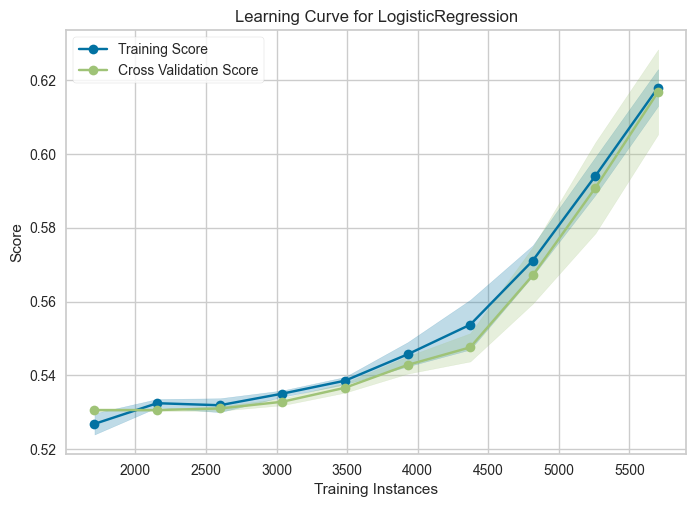

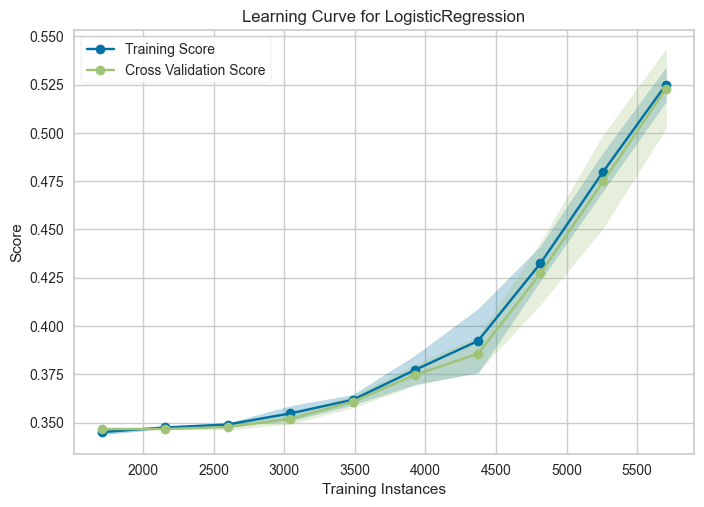

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

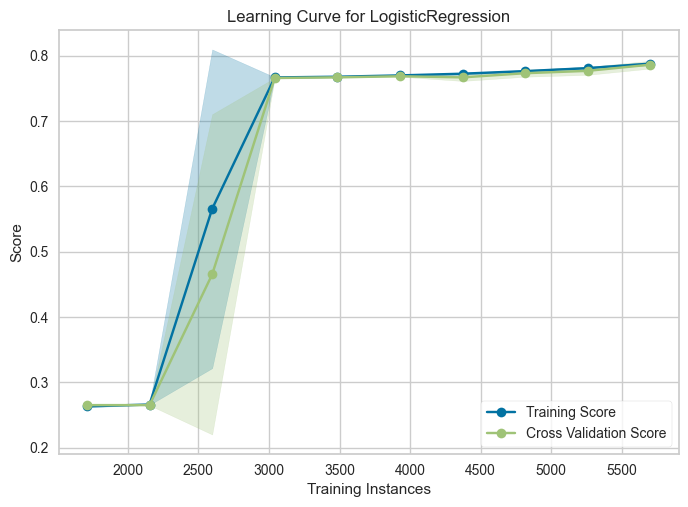

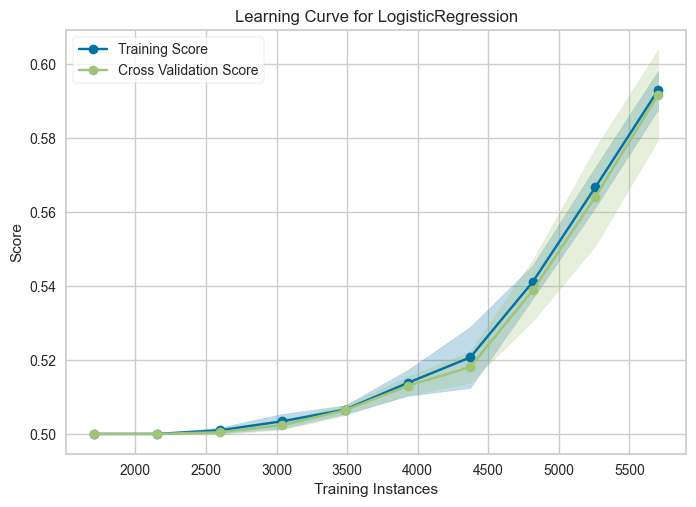

In [ ]:
metrics_touse = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
for metric in metrics_touse:
    visualizer = LearningCurve(
        LogisticRegression(), 
        scoring=metric, 
        train_sizes=np.linspace(0.3, 1.0, 10),
    ).fit(X, y).show()

# 2

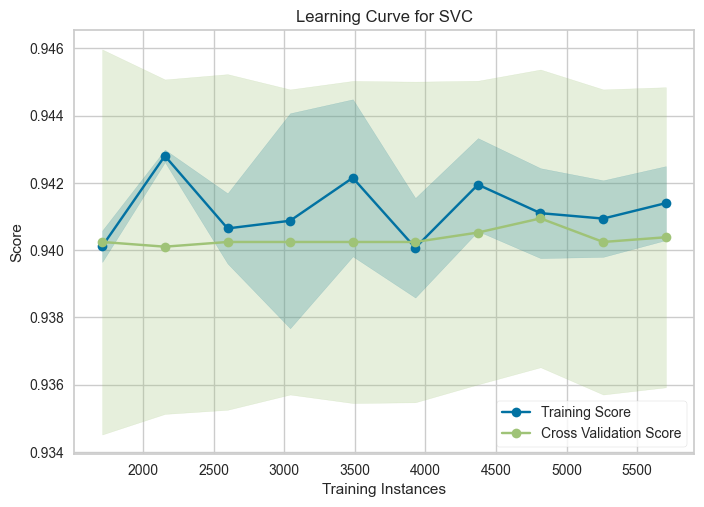

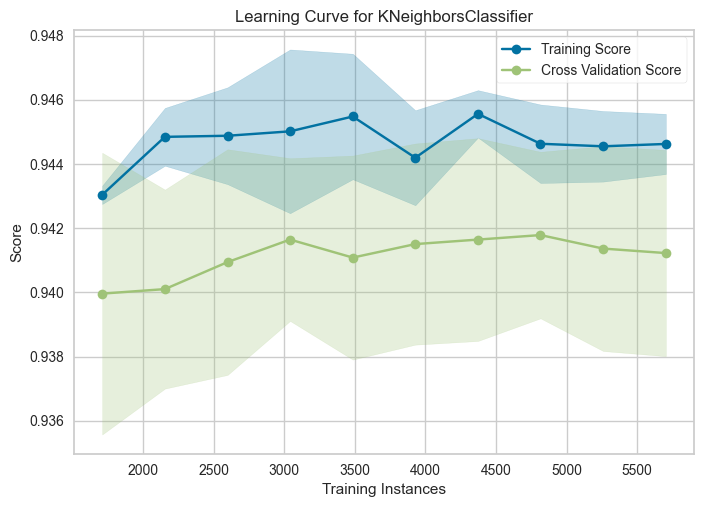

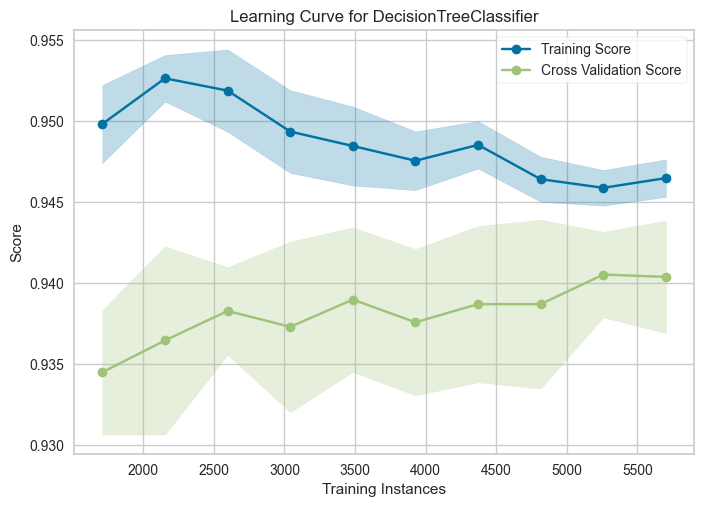

In [50]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
models = [SVC(), KNeighborsClassifier(n_neighbors=10), DecisionTreeClassifier(max_depth=5)]
for model in models:
    visualizer = LearningCurve(
        model, 
        scoring='accuracy', 
        train_sizes=np.linspace(0.3, 1.0, 10),
    ).fit(X, y).show()

# 3

In [51]:
# now this will not be accurate because i failed to find the correct dataset (broken link in the readme), so i found a random one from kaggle

dataset = genfromtxt('./data/boston-housing-dataset.csv', delimiter=',')  # had to import from kaggle, likely different
X = dataset[:,:-1]
y = dataset[:,-1]
X = np.delete(X, (0), axis=0)
y = np.delete(y, (0), axis=0)
X = np.delete(X, (0), axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

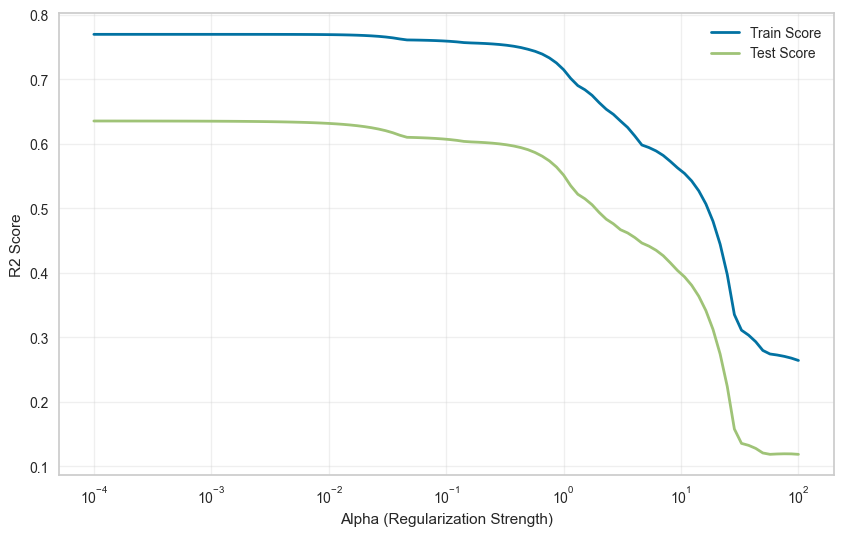


Optimal Alpha: 0.000100
Test Score at Optimal Alpha: 0.6354
Train Score at Optimal Alpha: 0.7698


In [52]:
trains = []
tests = []
alpha_values = np.logspace(-4, 2, 100)

for alpha in alpha_values:
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train, y_train)
    trains.append(lasso.score(X_train, y_train))
    tests.append(lasso.score(X_test, y_test))


plt.figure(figsize=(10, 6))
plt.plot(alpha_values, trains, label="Train Score", linewidth=2)
plt.plot(alpha_values, tests, label="Test Score", linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

optimal_idx = np.argmax(tests)
optimal_alpha = alpha_values[optimal_idx]
optimal_test_score = tests[optimal_idx]

print(f"\nOptimal Alpha: {optimal_alpha:.6f}")
print(f"Test Score at Optimal Alpha: {optimal_test_score:.4f}")
print(f"Train Score at Optimal Alpha: {trains[optimal_idx]:.4f}")


In [57]:
alpha_underfit = 10.0
model_underfit = Lasso(alpha=alpha_underfit, max_iter=10000)

model_optimal = Lasso(alpha=optimal_alpha, max_iter=10000)

alpha_overfit = 0.0001
model_overfit = Lasso(alpha=alpha_overfit, max_iter=10000)

models_to_compare = [
    (model_underfit, f"Underfitted ({alpha_underfit})"),
    (model_optimal, f"Optimal ({optimal_alpha:.6f})"),
    (model_overfit, f"Overfitted ({alpha_overfit})") # model gets trained instantly on my dataset unfortunately
]

for model, name in models_to_compare:
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    gap = train_score - test_score
    
    print(f"{name}")
    print(f"  Train Score: {train_score:.4f}")
    print(f"  Test Score:  {test_score:.4f}")
    print(f"  Gap (Overfitting): {gap:.4f}\n")

del models_to_compare[2]

Underfitted (10.0)
  Train Score: 0.5588
  Test Score:  0.3991
  Gap (Overfitting): 0.1597

Optimal (0.000100)
  Train Score: 0.7698
  Test Score:  0.6354
  Gap (Overfitting): 0.1343

Overfitted (0.0001)
  Train Score: 0.7698
  Test Score:  0.6354
  Gap (Overfitting): 0.1343



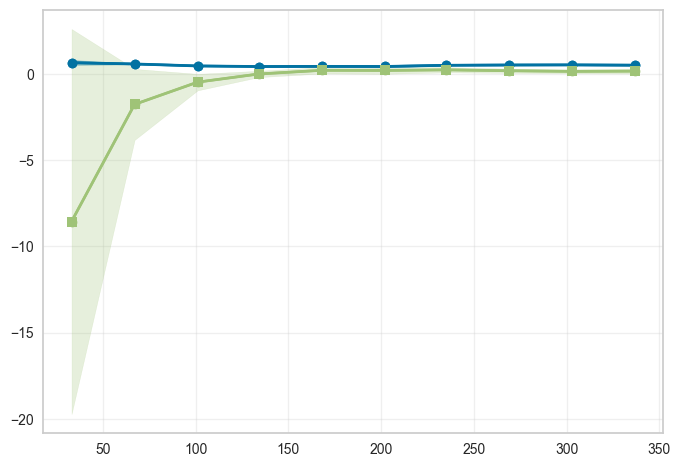

Underfitted (10.0)


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.257e+01, tolerance: 1.199e-01
  model = cd_fast.enet_coordinate_descent(
/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.257e+01, tolerance: 1.199e-01
  model = cd_fast.enet_coordinate_descent(


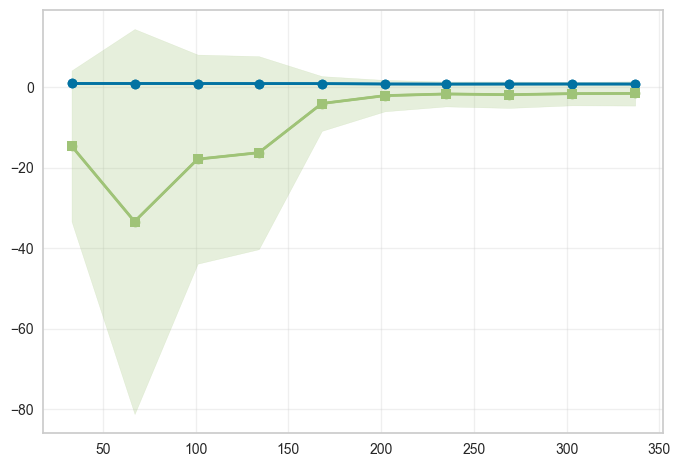

Optimal (0.000100)


In [64]:


for idx, (model, name) in enumerate(models_to_compare):
    visualizer = LearningCurve(
        model, 
        scoring='r2', 
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=3
    )
    visualizer.fit(X, y)
    
    plt.plot(visualizer.train_sizes_, visualizer.train_scores_.mean(axis=1), 
                   marker='o', label='Train Score', linewidth=2)
    plt.plot(visualizer.train_sizes_, visualizer.test_scores_.mean(axis=1), 
                   marker='s', label='Test Score', linewidth=2)
    plt.fill_between(visualizer.train_sizes_,
                           visualizer.train_scores_.mean(axis=1) - visualizer.train_scores_.std(axis=1),
                           visualizer.train_scores_.mean(axis=1) + visualizer.train_scores_.std(axis=1),
                           alpha=0.2)
    plt.fill_between(visualizer.train_sizes_,
                           visualizer.test_scores_.mean(axis=1),
                           visualizer.test_scores_.mean(axis=1),
                           alpha=0.2)
    plt.grid(True, alpha=0.3)
    plt.show()
    print(name)
    


# 4

In [65]:
X, y = make_classification(n_samples=10000, n_features=500, 
                           n_informative=50, n_repeated=0, 
                           class_sep=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=3)

In [70]:
from sklearn.linear_model import ElasticNet, Ridge
import time

alphas = np.logspace(-3, 2, 25)
l1_ratios = np.linspace(0.05, 1.0, 10)
results = np.zeros((len(l1_ratios), len(alphas)))
start_time = time.time()

for i, l1_ratio in enumerate(l1_ratios):
    print(f"Processing l1_ratio={l1_ratio:.2f}... ({i+1}/{len(l1_ratios)})")
    
    for j, alpha in enumerate(alphas):
        if l1_ratio == 0.0:
            model = Ridge(alpha=alpha)
        else:
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, 
                              max_iter=10000, random_state=42,
                              tol=1e-2)
        
        model.fit(X_train, y_train)
        results[i, j] = model.score(X_test, y_test)
    
    elapsed = time.time() - start_time
    avg_time_per_model = elapsed / ((i+1) * len(alphas))
    remaining_models = (len(l1_ratios) - i - 1) * len(alphas)
    estimated_remaining = remaining_models * avg_time_per_model
    
    print(f"  Elapsed: {elapsed:.1f}s | Est. remaining: {estimated_remaining:.1f}s\n")

print(f"\nTotal time: {time.time() - start_time:.1f} seconds")

Processing l1_ratio=0.05... (1/10)
  Elapsed: 65.8s | Est. remaining: 592.3s

Processing l1_ratio=0.16... (2/10)
  Elapsed: 103.0s | Est. remaining: 411.9s

Processing l1_ratio=0.26... (3/10)
  Elapsed: 126.9s | Est. remaining: 296.1s

Processing l1_ratio=0.37... (4/10)
  Elapsed: 147.1s | Est. remaining: 220.6s

Processing l1_ratio=0.47... (5/10)
  Elapsed: 162.4s | Est. remaining: 162.4s

Processing l1_ratio=0.58... (6/10)
  Elapsed: 174.6s | Est. remaining: 116.4s

Processing l1_ratio=0.68... (7/10)
  Elapsed: 184.9s | Est. remaining: 79.2s

Processing l1_ratio=0.79... (8/10)
  Elapsed: 193.7s | Est. remaining: 48.4s

Processing l1_ratio=0.89... (9/10)
  Elapsed: 201.5s | Est. remaining: 22.4s

Processing l1_ratio=1.00... (10/10)
  Elapsed: 208.6s | Est. remaining: 0.0s


Total time: 208.6 seconds


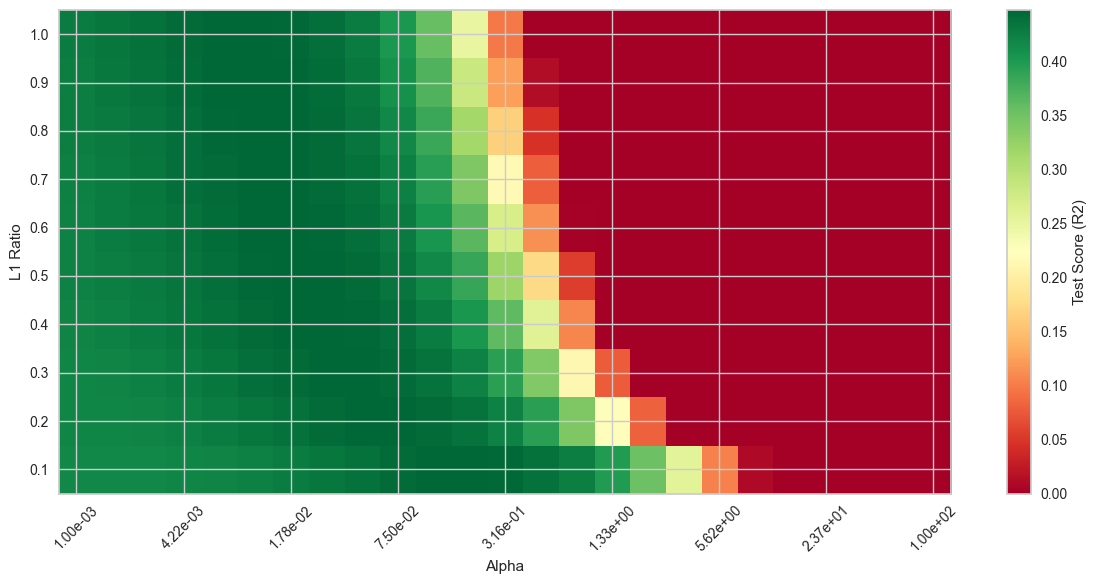

In [71]:
plt.figure(figsize=(12, 6))
im = plt.imshow(results, aspect='auto', origin='lower', cmap='RdYlGn')
plt.colorbar(im, label='Test Score (R2)')
plt.xlabel('Alpha')
plt.ylabel('L1 Ratio')

alpha_labels = [f'{a:.2e}' for a in alphas[::3]]
plt.xticks(range(0, len(alphas), 3), alpha_labels, rotation=45)

l1_labels = [f'{l:.1f}' for l in l1_ratios]
plt.yticks(range(len(l1_ratios)), l1_labels)

plt.tight_layout()
plt.show()

In [74]:
optimal_idx = np.unravel_index(np.argmax(results), results.shape)
optimal_l1_ratio = l1_ratios[optimal_idx[0]]
optimal_alpha = alphas[optimal_idx[1]]
optimal_score = results[optimal_idx]

print(f"Best L1 Ratio: {optimal_l1_ratio:.2f}")
print(f"Best Alpha: {optimal_alpha:.6f}")
print(f"Best Test Score: {optimal_score:.4f}")

Best L1 Ratio: 1.00
Best Alpha: 0.011007
Best Test Score: 0.4482


# 5

In [76]:
df = pd.read_csv('./data/diabetes.csv')
target = "Outcome"
y = df[target]
X = df.drop(target, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
max_depths = np.arange(1, 31)
train_scores_acc = []
test_scores_acc = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_scores_acc.append(accuracy_score(y_train, train_pred))
    test_scores_acc.append(accuracy_score(y_test, test_pred))

optimal_idx_acc = np.argmax(test_scores_acc)
optimal_depth_acc = max_depths[optimal_idx_acc]
optimal_test_acc = test_scores_acc[optimal_idx_acc]
optimal_train_acc = train_scores_acc[optimal_idx_acc]

In [86]:
train_scores_f1 = []
test_scores_f1 = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_scores_f1.append(f1_score(y_train, train_pred))
    test_scores_f1.append(f1_score(y_test, test_pred))

optimal_idx_f1 = np.argmax(test_scores_f1)
optimal_depth_f1 = max_depths[optimal_idx_f1]
optimal_test_f1 = test_scores_f1[optimal_idx_f1]
optimal_train_f1 = train_scores_f1[optimal_idx_f1]

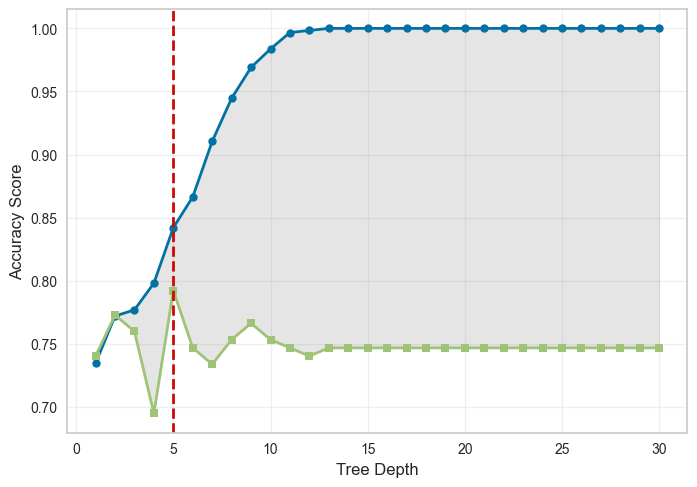

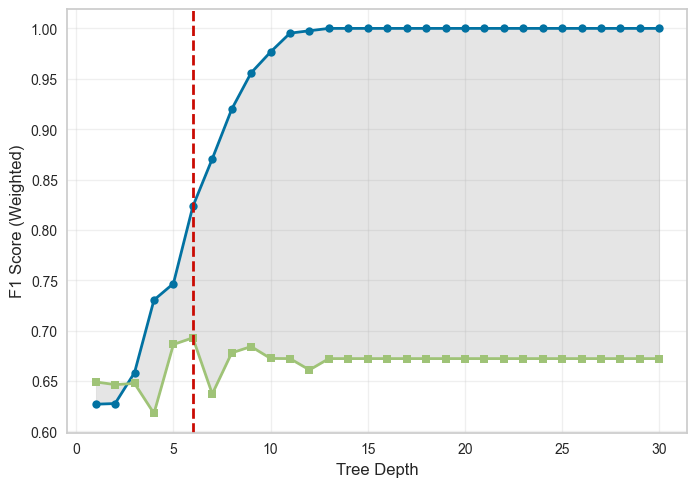

In [89]:
plt.plot(max_depths, train_scores_acc, marker='o', label='Train Accuracy', 
             linewidth=2, markersize=6)
plt.plot(max_depths, test_scores_acc, marker='s', label='Test Accuracy', 
             linewidth=2, markersize=6)
plt.axvline(x=optimal_depth_acc, color='r', linestyle='--', 
                label=f'Optimal (depth={optimal_depth_acc})', linewidth=2)
plt.fill_between(max_depths, train_scores_acc, test_scores_acc, 
                     alpha=0.2, color='gray', label='Overfitting Gap')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 31, 5))
plt.show()


plt.plot(max_depths, train_scores_f1, marker='o', label='Train F1', 
             linewidth=2, markersize=6)
plt.plot(max_depths, test_scores_f1, marker='s', label='Test F1', 
             linewidth=2, markersize=6)
plt.axvline(x=optimal_depth_f1, color='r', linestyle='--', 
                label=f'Optimal (depth={optimal_depth_f1})', linewidth=2)
plt.fill_between(max_depths, train_scores_f1, test_scores_f1, 
                     alpha=0.2, color='gray', label='Overfitting Gap')
plt.xlabel('Tree Depth', fontsize=12)
plt.ylabel('F1 Score (Weighted)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 31, 5))
plt.show()

# 6

In [94]:
def analyze_tree_depth(name, X, y, max_depth_range=30, test_size=0.2, random_state=42):
    if hasattr(X, 'select_dtypes'):
        X = pd.get_dummies(X, drop_first=True)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, 
        stratify=y if len(np.unique(y)) > 1 else None
    )
    
    best_score = -np.inf
    best_depth = 1
    train_scores = []
    test_scores = []
    depths = np.arange(1, max_depth_range + 1)
    
    for depth in depths:
        try:
            model = DecisionTreeClassifier(max_depth=depth, random_state=random_state)
            model.fit(X_train, y_train)
            train_scores.append(accuracy_score(y_train, model.predict(X_train)))
            test_score = accuracy_score(y_test, model.predict(X_test))
            test_scores.append(test_score)
            
            if test_score > best_score:
                best_score = test_score
                best_depth = depth
        except:
            continue
    
    X_full = np.vstack([X_train, X_test])
    y_full = np.concatenate([y_train, y_test])
    model_full = DecisionTreeClassifier(max_depth=best_depth, random_state=random_state)
    model_full.fit(X_full, y_full)
    full_acc = accuracy_score(y_full, model_full.predict(X_full))
    
    return {
        'name': name,
        'shape': X.shape,
        'optimal_depth': best_depth,
        'test_acc': best_score,
        'train_acc': train_scores[best_depth - 1],
        'full_acc': full_acc,
        'gap': train_scores[best_depth - 1] - best_score,
        'depths': depths,
        'train_scores': train_scores,
        'test_scores': test_scores,
    }

In [95]:
dataset_names = [
    'phoneme', 'banknote-authentication', 'delta_ailerons', 'mammography',
    'electricity', 'mozilla4', 'kropt', 'nursery', 'volcanoes-b3'
]

results = []

for name in dataset_names:
    data = fetch_openml(name=name, parser='auto')
    X = pd.get_dummies(data.data, drop_first=True) if hasattr(data.data, 'select_dtypes') else data.data
    y = data.target
    
    if X.shape[1] > 500 or len(X) < 50:
        continue
    
    result = analyze_tree_depth(name, X, y)
    results.append(result)
    print(f"{name:25s} | Opt.Depth: {result['optimal_depth']:2d} | Test: {result['test_acc']:.4f} | Full: {result['full_acc']:.4f} | Gap: {result['gap']:.4f}")

/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name phoneme exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1489
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43973

  warn(warning_msg)


phoneme                   | Opt.Depth: 11 | Test: 0.8677 | Full: 0.9482 | Gap: 0.0955
banknote-authentication   | Opt.Depth:  5 | Test: 0.9927 | Full: 0.9840 | Gap: 0.0018
delta_ailerons            | Opt.Depth:  4 | Test: 0.9432 | Full: 0.9432 | Gap: -0.0037
mammography               | Opt.Depth:  8 | Test: 0.9875 | Full: 0.9939 | Gap: 0.0051


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name electricity exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=151
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=43945

  warn(warning_msg)


electricity               | Opt.Depth: 18 | Test: 0.8755 | Full: 0.9711 | Gap: 0.1069
mozilla4                  | Opt.Depth: 12 | Test: 0.9495 | Full: 0.9718 | Gap: 0.0258
kropt                     | Opt.Depth: 30 | Test: 0.6064 | Full: 0.9984 | Gap: 0.3927


/Users/tedvtorov/Desktop/py-proj/MISIS/misis_ml_course_sem6/venv/lib/python3.12/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name nursery exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=26
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=959

  warn(warning_msg)


nursery                   | Opt.Depth: 16 | Test: 0.9892 | Full: 0.9994 | Gap: 0.0102
volcanoes-b3              | Opt.Depth:  2 | Test: 0.9654 | Full: 0.9676 | Gap: 0.0024
